## Import/Load Data

In [7]:
#Import libraries
# Data Processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import RandomizedSearchCV, train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
import xgboost as xgb

# Hyperparameter Tuning
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.linear_model import LogisticRegression

# Hyperparameter Tuning
from scipy.stats import randint

# Tree Visualisation
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

In [8]:
#Load data
test = pd.read_csv('test.csv', index_col='id')
train = pd.read_csv('train.csv', index_col='id')

## Data Exploration

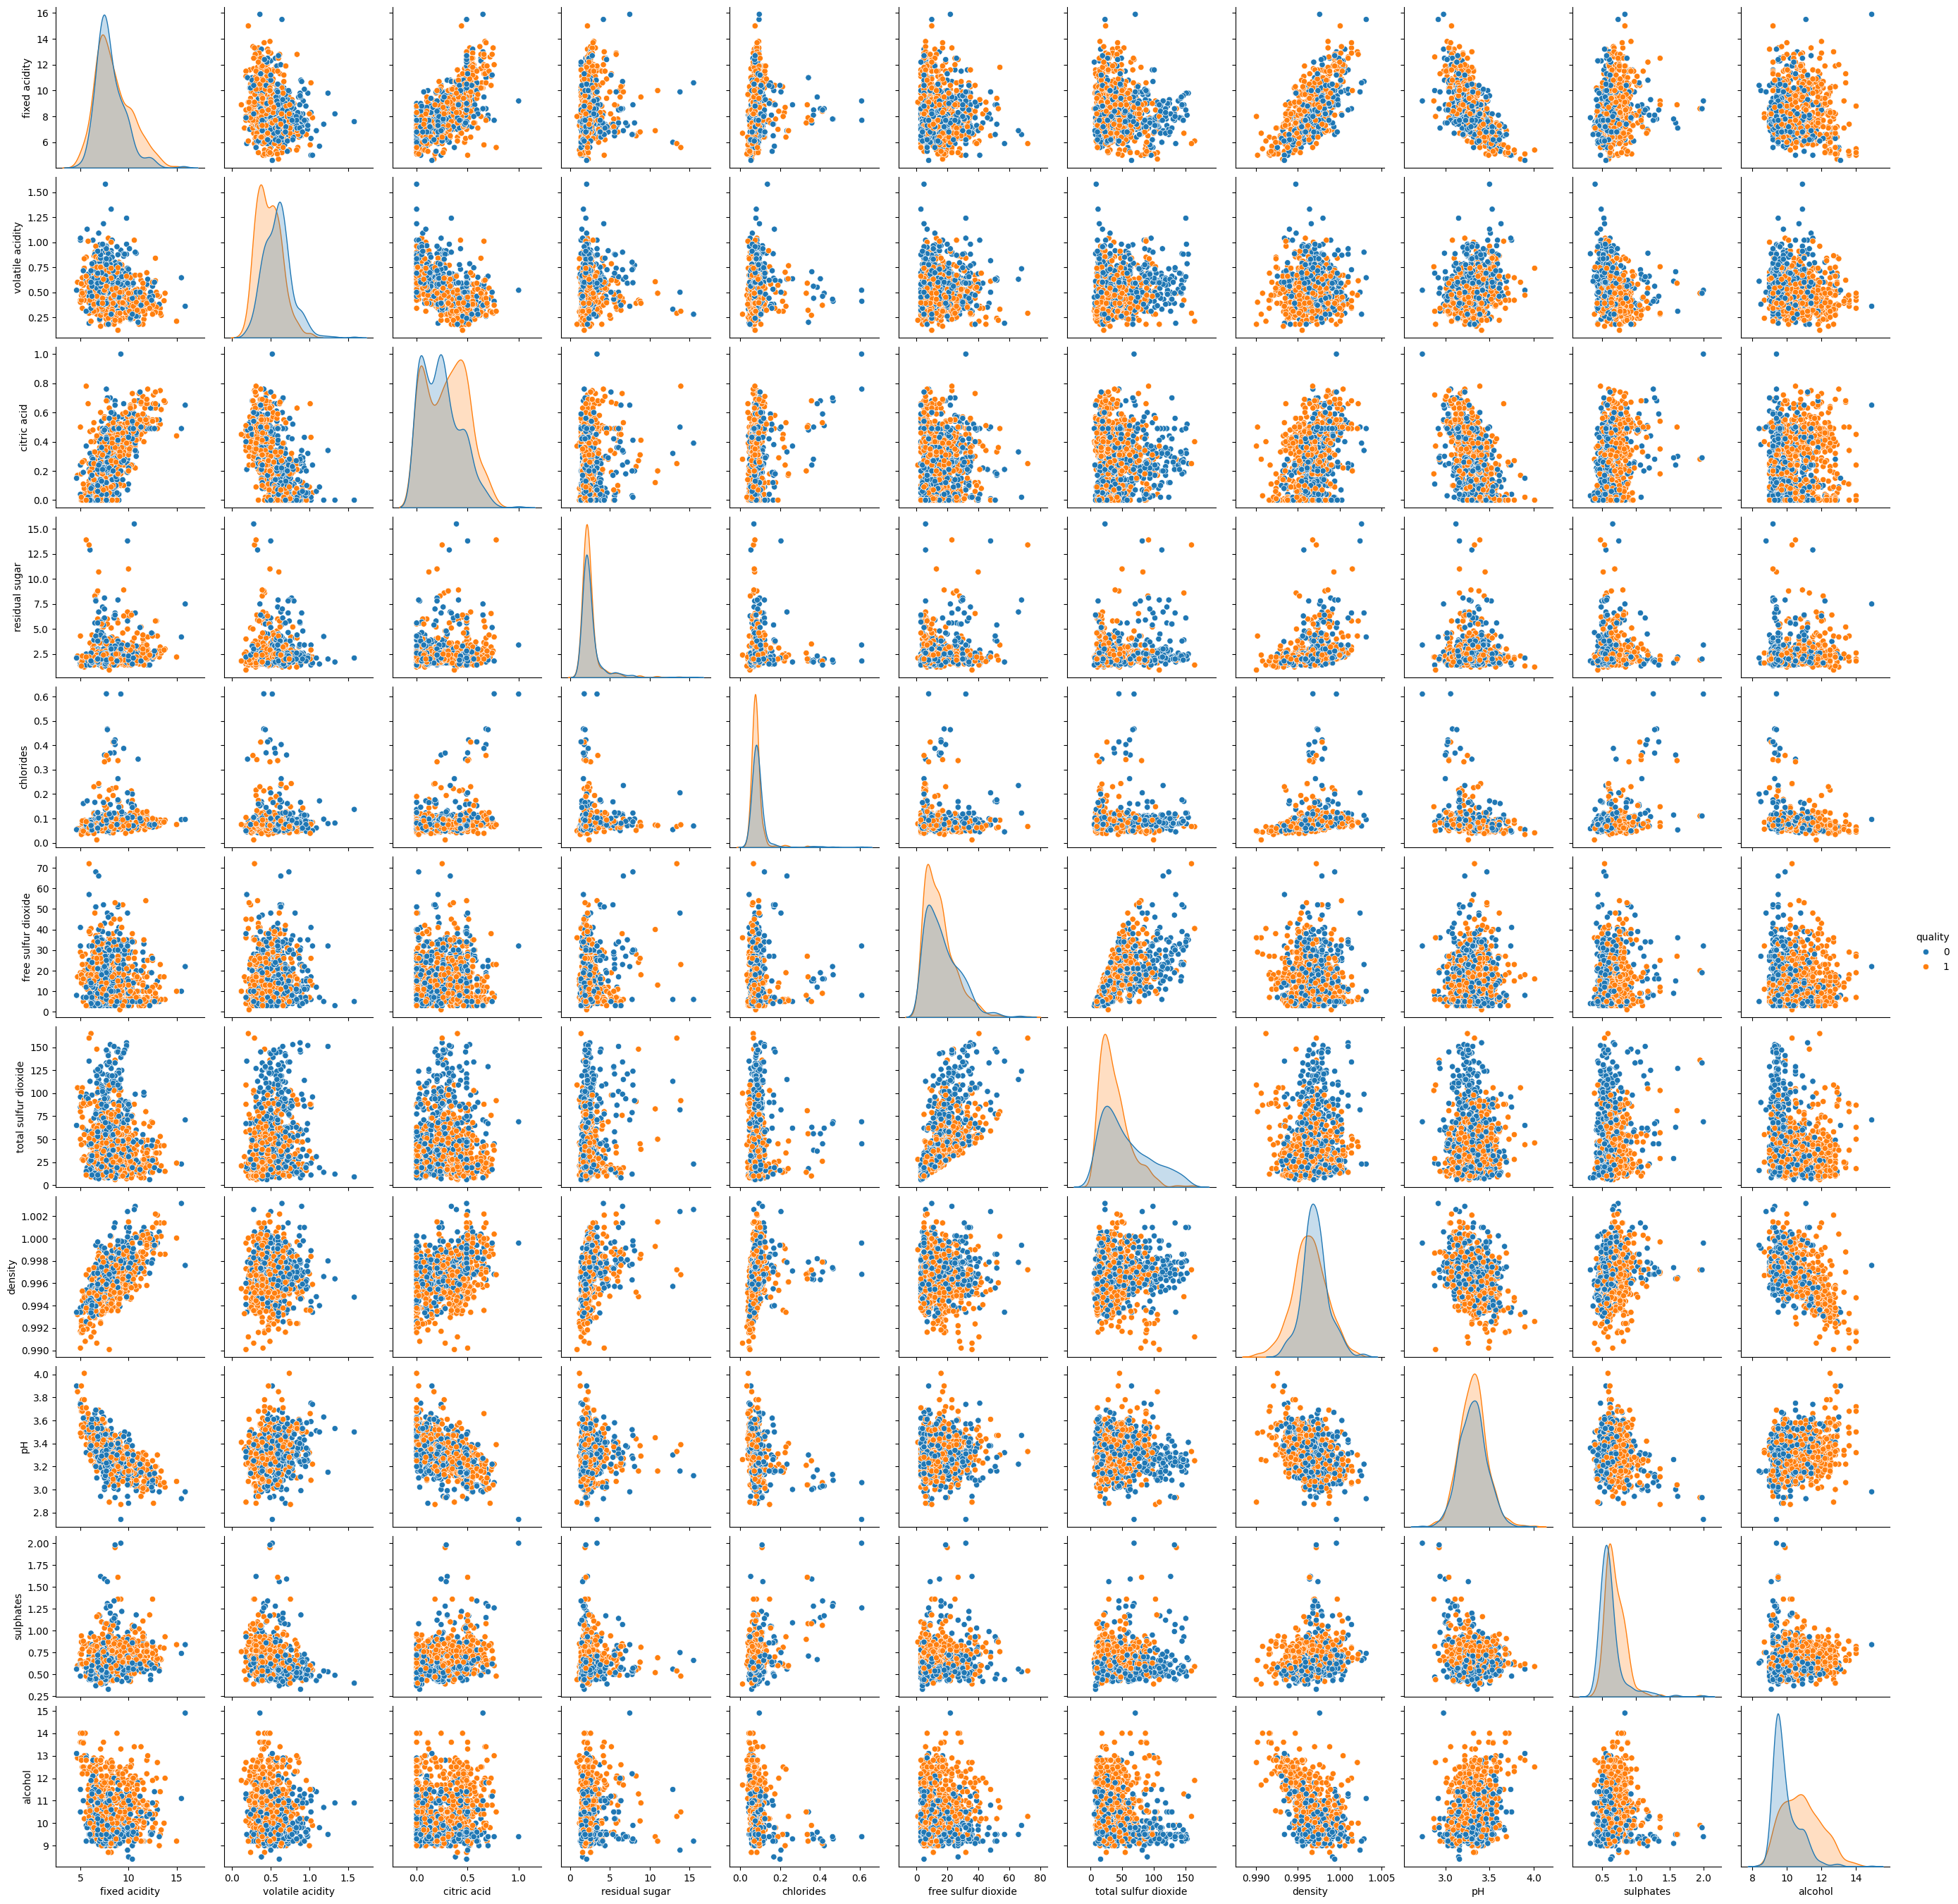

In [9]:
sns.pairplot(train, hue='quality')

## Model Building

In [10]:
#Prep training data
features = train.drop('quality', axis=1)
target = train['quality']

In [11]:
np.random.seed(42)
#Create training sets
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2)

#Normalize data
#norm = MinMaxScaler()
#x_train = norm.fit_transform(x_train)
#x_test = norm.transform(x_test)

              precision    recall  f1-score   support

           0       0.81      0.79      0.80       100
           1       0.83      0.85      0.84       124

    accuracy                           0.83       224
   macro avg       0.82      0.82      0.82       224
weighted avg       0.83      0.83      0.83       224



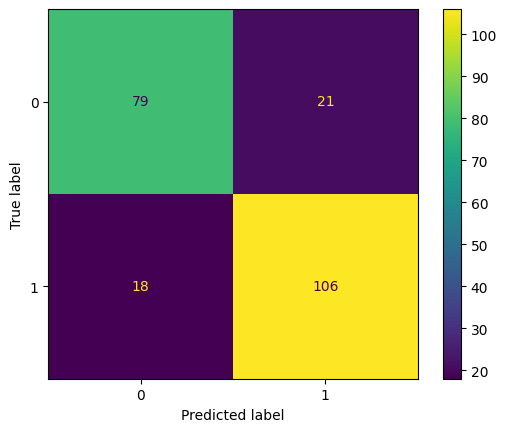

In [12]:
#Model building
np.random.seed(42)
rfc_tuned = RandomForestClassifier(n_estimators=320, min_samples_split=2, min_samples_leaf=2, max_depth=16, bootstrap=True)
rfc_tuned.fit(x_train, y_train)
y_pred = rfc_tuned.predict(x_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

In [13]:
rfc_tuned.fit(features, target)
rfc_predictions = rfc_tuned.predict(test)

## Ensemble Learning

In [14]:
from sklearn.ensemble import VotingClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# Create ensemble
rf = RandomForestClassifier(n_estimators=320, min_samples_split=2, min_samples_leaf=2, max_depth=16, bootstrap=True, random_state=42)
gb = GradientBoostingClassifier(random_state=42)
svc = SVC(probability=True, random_state=42)

ensemble = VotingClassifier([('rf', rf), ('gb', gb), ('svc', svc)], voting='soft')
ensemble.fit(x_train, y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=16,
                                                     min_samples_leaf=2,
                                                     n_estimators=320,
                                                     random_state=42)),
                             ('gb',
                              GradientBoostingClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))],
                 voting='soft')

              precision    recall  f1-score   support

           0       0.77      0.70      0.73       100
           1       0.77      0.83      0.80       124

    accuracy                           0.77       224
   macro avg       0.77      0.77      0.77       224
weighted avg       0.77      0.77      0.77       224



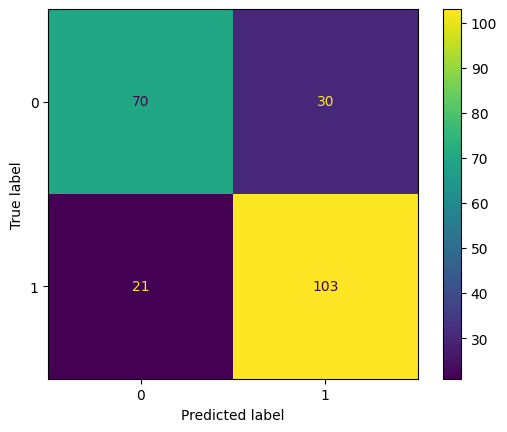

In [15]:
y_pred = ensemble.predict(x_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm).plot()

## Print Results

In [16]:
results = pd.DataFrame({'id': test.index, 'quality': rfc_predictions})
results.to_csv('resultsv3.csv', index=False)